In [1]:
# 1. IMPORTS

import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
import joblib

In [2]:
# 2. LOAD DATA

df = pd.read_csv("BankLiquidityRiskDetection (1).csv")

In [45]:
df.head()

,01_CURR_ACC,02_TIME_DEPOSIT,03_SAVINGS,04_OTHER_DEPOSITS,05_BANKS_DEPOSITS,06_BORROWING_FROM_PUBLIC,07_INTERBANKS_LOAN_PAYABLE,08_CHEQUES_ISSUED,09_PAY_ORDERS,10_FOREIGN_DEPOSITS_AND_BORROWINGS,...,EWAQ_Capital,EWAQ_NPL,EWAQ_NPLsNetOfProvisions,EWAQ_NPLsNetOfProvisions2CoreCapital,LR,DR,IBCM,GDP,INF,MLA_CLASS2
0,4.358491e+10,7.636494e+09,1.834680e+10,1052155.45,0.0,0.0,1.486844e+09,7.642781e+07,-5.985489e+08,-3.637892e+09,...,1.223832e+10,8.063249e+08,44468.326344,0.000003,14.634353,6.275245,1.314727,6.178466,10.973782,1
1,4.198509e+10,7.603740e+09,1.827224e+10,1052155.45,0.0,0.0,1.669462e+09,8.905947e+07,-6.895085e+07,-3.941001e+09,...,1.226051e+10,8.206735e+08,59291.101792,0.000004,14.635804,6.250326,1.315636,6.113955,10.765043,1
2,4.139788e+10,7.647355e+09,1.785701e+10,1052155.45,0.0,0.0,1.839116e+09,1.335379e+08,2.365688e+07,-4.033022e+09,...,1.227214e+10,8.167797e+08,51879.714068,0.000004,14.640078,6.222785,1.331181,5.982211,10.549412,1
3,4.083612e+10,8.152346e+09,1.859316e+10,1052155.45,0.0,0.0,1.850474e+09,1.217606e+08,2.136560e+08,2.585589e+08,...,1.227576e+10,7.985373e+08,29645.550896,0.000002,14.646235,6.193496,1.356484,5.805644,10.329188,1
4,4.533415e+10,8.091856e+09,1.862976e+10,1052155.45,0.0,0.0,1.843065e+09,1.099271e+08,5.561149e+07,1.162978e+09,...,1.226926e+10,7.345822e+08,-29645.550896,-0.000002,14.660432,6.133170,1.416849,5.407689,9.884145,1


In [47]:
df.isnull().sum()

01_CURR_ACC                             0
02_TIME_DEPOSIT                         0
03_SAVINGS                              0
04_OTHER_DEPOSITS                       0
05_BANKS_DEPOSITS                       0
06_BORROWING_FROM_PUBLIC                0
07_INTERBANKS_LOAN_PAYABLE              0
08_CHEQUES_ISSUED                       0
09_PAY_ORDERS                           0
10_FOREIGN_DEPOSITS_AND_BORROWINGS      0
11_OFF_BALSHEET_COMMITMENTS             0
12_OTHER_LIABILITIES                    0
13_CASH                                 0
14_CURRENT_ACC                          0
15_SMR_ACC                              0
16_FOREIGN CURRENCY                     0
17_OTHER DEPOSITS                       0
18_BANKS_TZ                             0
19_BANKS_ABROAD                         0
20_CHEQUES_ITEMS_FOR_CLEARING           0
21_INTERBANK_LOANS                      0
22_TREASURY_BILLS                       0
23_OTHER_GOV_SECURITIES                 0
24_FOREIGN_CURRENCY               

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20878 entries, 0 to 20877
Data columns (total 44 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   01_CURR_ACC                           20878 non-null  float64
 1   02_TIME_DEPOSIT                       20878 non-null  float64
 2   03_SAVINGS                            20878 non-null  float64
 3   04_OTHER_DEPOSITS                     20878 non-null  float64
 4   05_BANKS_DEPOSITS                     20878 non-null  float64
 5   06_BORROWING_FROM_PUBLIC              20878 non-null  float64
 6   07_INTERBANKS_LOAN_PAYABLE            20878 non-null  float64
 7   08_CHEQUES_ISSUED                     20878 non-null  float64
 8   09_PAY_ORDERS                         20878 non-null  float64
 9   10_FOREIGN_DEPOSITS_AND_BORROWINGS    20878 non-null  float64
 10  11_OFF_BALSHEET_COMMITMENTS           20878 non-null  float64
 11  12_OTHER_LIABIL

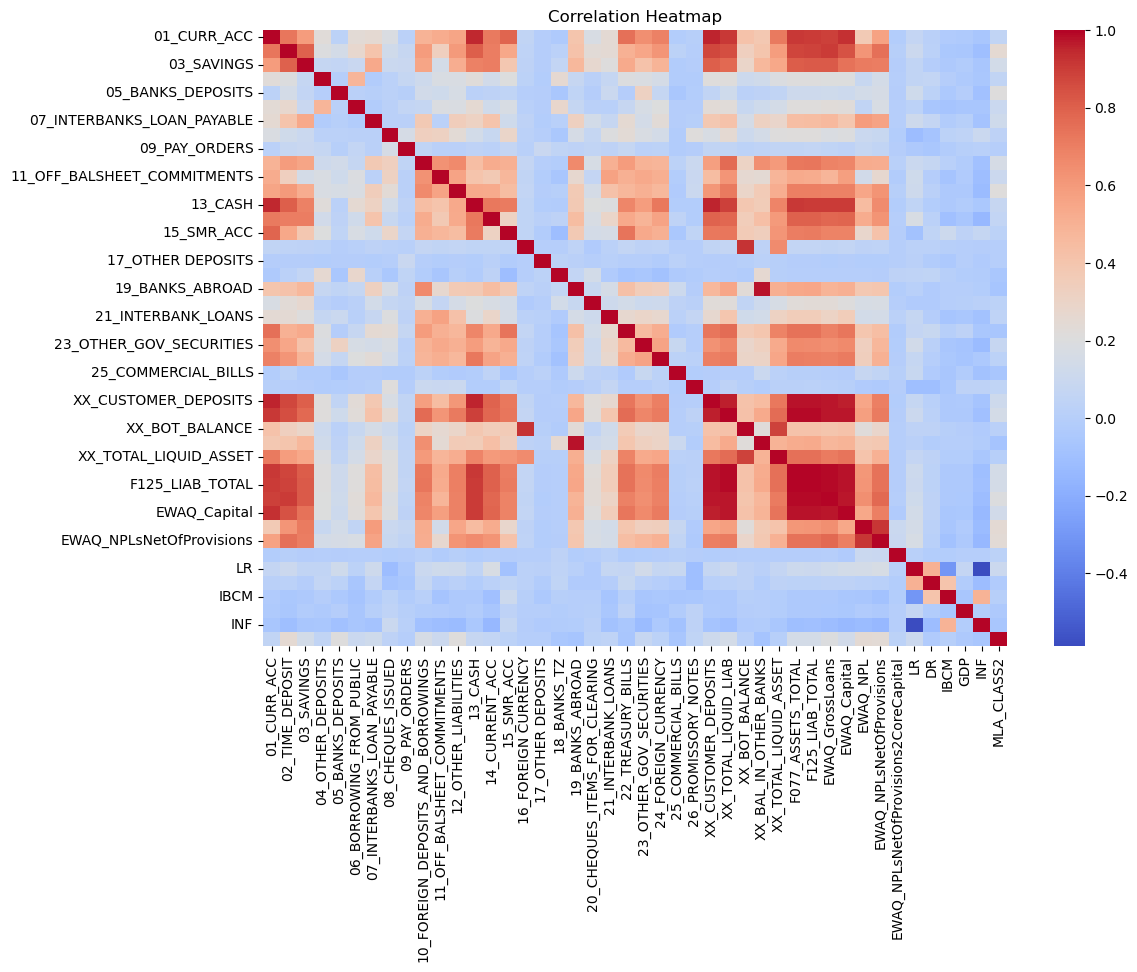

In [59]:
# Correlation
corr = df.corr()

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap")
plt.show()

In [3]:
# 3. CLEAN DATA

df = df.drop(columns=[
    "Unnamed: 0",
    "REPORTINGDATE",
    "INSTITUTIONCODE",
    "MLA",
    "XX_MLA",
    "XX_MLA_CLASS2",
    "EWL_LIQUIDITY RATING"
], errors='ignore')

In [4]:
# 4. FEATURES & TARGET

X = df.drop(columns=["MLA_CLASS2"])
y = df["MLA_CLASS2"] - 1   # convert 1–5 → 0–4

print(" ORIGINAL CLASS DISTRIBUTION:")
print(y.value_counts())

 ORIGINAL CLASS DISTRIBUTION:
MLA_CLASS2
0    9012
1    5886
2    5112
4     553
3     315
Name: count, dtype: int64


In [5]:
# 5. FEATURE SELECTION

temp_model = XGBClassifier(n_estimators=200, random_state=42)
temp_model.fit(X, y)

importance = pd.Series(temp_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(25).index

X = X[top_features]

In [6]:
# 6. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

In [7]:
# 7. SCALING

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# 8. HANDLE IMBALANCE (SMOTE)

sm = SMOTE(sampling_strategy='not majority', random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("\n🔍 AFTER SMOTE CLASS DISTRIBUTION:")
print(pd.Series(y_train).value_counts())


🔍 AFTER SMOTE CLASS DISTRIBUTION:
MLA_CLASS2
0    6759
2    6759
3    6759
1    6759
4    6759
Name: count, dtype: int64


In [9]:
# 9. CLASS WEIGHTS

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))
sample_weights = np.array([class_weights[i] for i in y_train])

In [10]:
# 10. MODEL (ANTI-OVERFITTING)
model = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',

    max_depth=5,
    learning_rate=0.05,
    n_estimators=500,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.5,
    reg_lambda=1.0,
    gamma=1,

    random_state=42
)

In [11]:
# 11. TRAIN MODEL

model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=5, ...)

In [12]:
# 12. PREDICTION

probs = model.predict_proba(X_test)
y_pred = np.argmax(probs, axis=1)

In [13]:
# 13. VALIDATION CHECKS
# Actual vs Predicted Distribution
print("\n ACTUAL CLASS DISTRIBUTION:")
print(pd.Series(y_test).value_counts())

print("\n PREDICTED CLASS DISTRIBUTION:")
print(pd.Series(y_pred).value_counts())

# Unique Classes
print("\n UNIQUE CLASSES PREDICTED:")
print(np.unique(y_pred))

# Accuracy
print("\n Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\n CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\n CONFUSION MATRIX:\n")
print(confusion_matrix(y_test, y_pred))

# Probability Check
print("\n SAMPLE PROBABILITIES:")
print(probs[:5])

# Confidence
confidence = np.max(probs, axis=1)
print("\n AVERAGE CONFIDENCE:", np.mean(confidence))

# Train vs Test Accuracy (overfitting check)
print("\n TRAIN ACCURACY:", model.score(X_train, y_train))
print(" TEST ACCURACY:", model.score(X_test, y_test))


 ACTUAL CLASS DISTRIBUTION:
MLA_CLASS2
0    2253
1    1472
2    1278
4     138
3      79
Name: count, dtype: int64

 PREDICTED CLASS DISTRIBUTION:
0    2184
1    1557
2    1231
4     157
3      91
Name: count, dtype: int64

 UNIQUE CLASSES PREDICTED:
[0 1 2 3 4]

 Accuracy: 0.8885057471264368

 CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      2253
           1       0.82      0.87      0.85      1472
           2       0.90      0.87      0.88      1278
           3       0.51      0.58      0.54        79
           4       0.71      0.81      0.76       138

    accuracy                           0.89      5220
   macro avg       0.78      0.81      0.79      5220
weighted avg       0.89      0.89      0.89      5220


 CONFUSION MATRIX:

[[2089  147    5    2   10]
 [  83 1282   99    2    6]
 [   4  124 1109   25   16]
 [   3    4   13   46   13]
 [   5    0    5   16  112]]

 SAMPLE PROBABILITIES:
[[9.

In [43]:

# 14. SAVE MODEL FILES

joblib.dump(model, "liquidity_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(top_features, "features.pkl")

print("\n✅ Model, Scaler, Features saved successfully!")


✅ Model, Scaler, Features saved successfully!
